## Import libraries

In [435]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [475]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

## Import files

In [436]:
df = pd.read_csv("loanprediction.csv")

In [437]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



## Missing values

## 

In [438]:
(df.isnull().mean() * 100)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [439]:
df["Gender"] = df["Gender"].fillna(df["Gender"].ffill())
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].ffill())

In [440]:
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])


In [441]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [442]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])


In [443]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].bfill())


In [444]:
(df.isnull().mean() * 100)

Loan_ID              0.000000
Gender               0.000000
Married              0.488599
Dependents           0.000000
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

## check datatypes

In [445]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [446]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

## EDA 


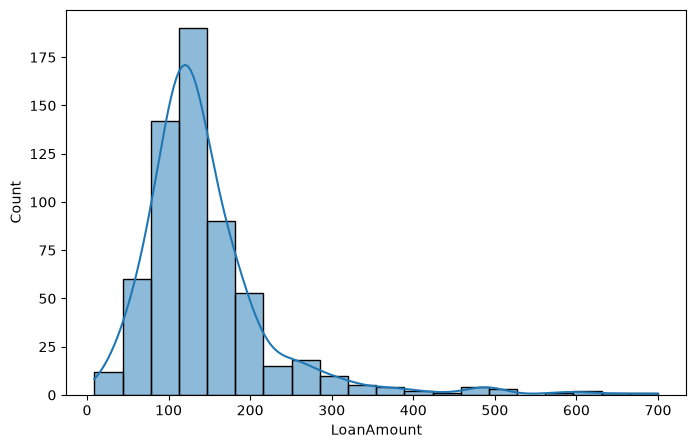

In [447]:
plt.figure(figsize=(8,5))
sns.histplot(df["LoanAmount"], bins=20, kde=True)
plt.show()

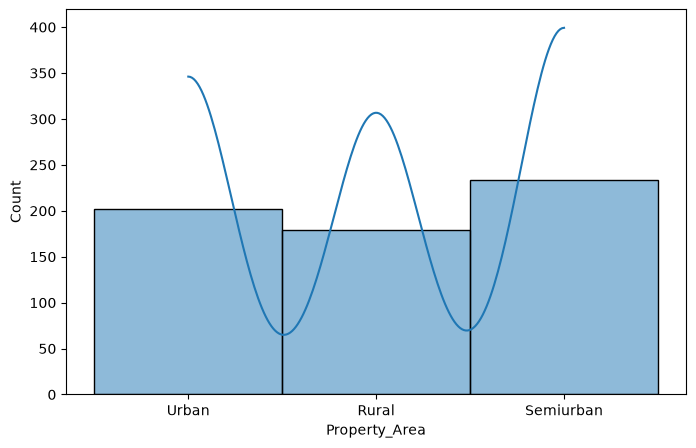

In [448]:
plt.figure(figsize=(8,5))
sns.histplot(df["Property_Area"], bins=20, kde=True)
plt.show()

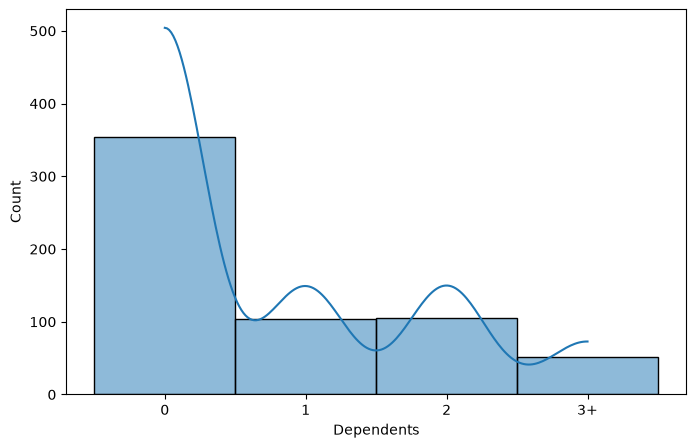

In [449]:
plt.figure(figsize=(8,5))
sns.histplot(df["Dependents"], bins=20, kde=True)
plt.show()

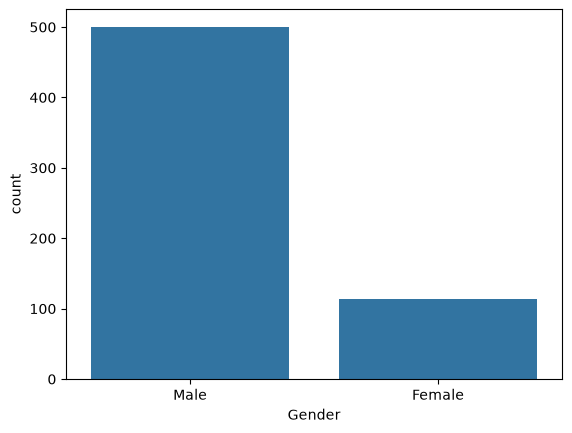

In [450]:
sns.countplot(x="Gender",data=df)
plt.show()

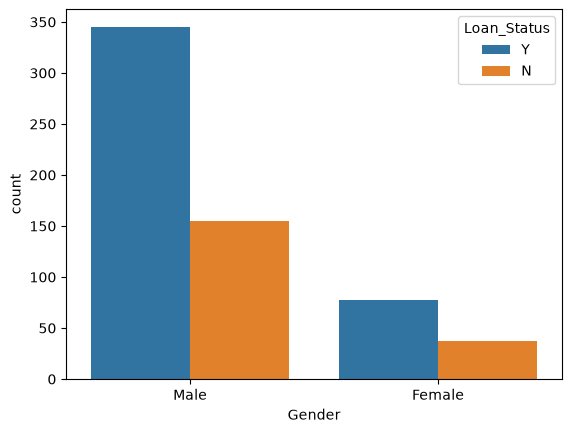

In [451]:
sns.countplot(x="Gender",hue="Loan_Status",data=df)
plt.show()

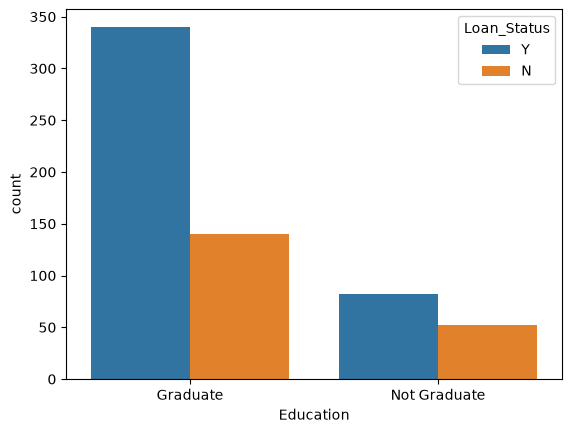

In [452]:
sns.countplot(x="Education",hue="Loan_Status",data=df)
plt.show()

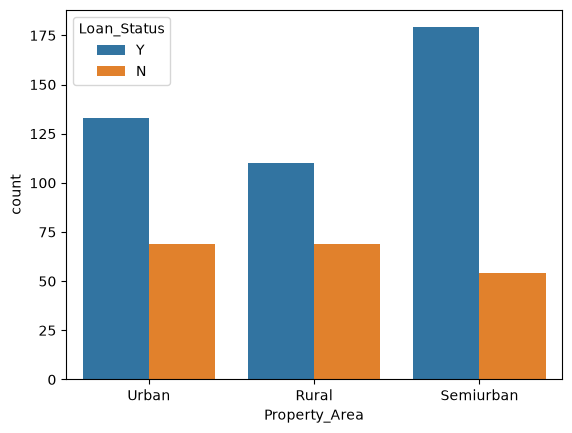

In [453]:
sns.countplot(x="Property_Area",hue="Loan_Status",data=df)
plt.show()

# Feature engineering


In [454]:
(df.isnull().mean() * 100)

Loan_ID              0.000000
Gender               0.000000
Married              0.488599
Dependents           0.000000
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [455]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

In [456]:
df["Income_Loan_Ratio"] = df["TotalIncome"] / df["LoanAmount"]

## Bining

In [457]:
df["Income_Bin"] = pd.qcut(df["TotalIncome"],4)

In [458]:
df["Loan_Bin"] = pd.qcut(df["LoanAmount"],4)

In [459]:
(df.isnull().mean() * 100)

Loan_ID              0.000000
Gender               0.000000
Married              0.488599
Dependents           0.000000
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
TotalIncome          0.000000
Income_Loan_Ratio    0.000000
Income_Bin           0.000000
Loan_Bin             0.000000
dtype: float64

In [460]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Loan_ID            614 non-null    str     
 1   Gender             614 non-null    str     
 2   Married            611 non-null    str     
 3   Dependents         614 non-null    str     
 4   Education          614 non-null    str     
 5   Self_Employed      614 non-null    str     
 6   ApplicantIncome    614 non-null    int64   
 7   CoapplicantIncome  614 non-null    float64 
 8   LoanAmount         614 non-null    float64 
 9   Loan_Amount_Term   614 non-null    float64 
 10  Credit_History     614 non-null    float64 
 11  Property_Area      614 non-null    str     
 12  Loan_Status        614 non-null    str     
 13  TotalIncome        614 non-null    float64 
 14  Income_Loan_Ratio  614 non-null    float64 
 15  Income_Bin         614 non-null    category
 16  Loan_Bin           

In [461]:
df.Gender.value_counts()

Gender
Male      500
Female    114
Name: count, dtype: int64

# Encoding

In [462]:
df_encoded = df[[
    "Gender",
    "Dependents",
    "Education",
    "Self_Employed",
    "LoanAmount",
    "Loan_Amount_Term",
    "Property_Area",
    "Loan_Status",
    "TotalIncome",
    "Income_Bin",
    "Loan_Bin"
]]

In [463]:
df_encoded["Dependents"] = df_encoded["Dependents"].replace("3+","3")


In [464]:
df_encoded["Loan_Status"] = df_encoded["Loan_Status"].map({"Y":1,"N":0})
df_encoded["Gender"] = df_encoded["Gender"].map({"Male":1,"Female":0})
df_encoded["Education"] = df_encoded["Education"].map({"Graduate":1,"Not Graduate":0})
df_encoded["Self_Employed"] = df_encoded["Self_Employed"].map({"Yes":1,"No":0})

In [465]:
df_encoded.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [466]:
df_encoded= pd.get_dummies(df_encoded,columns=["Property_Area", "Income_Bin", "Loan_Bin"],drop_first=True)

In [467]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         614 non-null    int64  
 1   Dependents                     614 non-null    str    
 2   Education                      614 non-null    int64  
 3   Self_Employed                  614 non-null    int64  
 4   LoanAmount                     614 non-null    float64
 5   Loan_Amount_Term               614 non-null    float64
 6   Loan_Status                    614 non-null    int64  
 7   TotalIncome                    614 non-null    float64
 8   Property_Area_Semiurban        614 non-null    bool   
 9   Property_Area_Urban            614 non-null    bool   
 10  Income_Bin_(4166.0, 5416.5]    614 non-null    bool   
 11  Income_Bin_(5416.5, 7521.75]   614 non-null    bool   
 12  Income_Bin_(7521.75, 81000.0]  614 non-null    bool   
 13  L

In [468]:
(df_encoded.isnull().sum() / len(df_encoded)) * 100

Gender                           0.0
Dependents                       0.0
Education                        0.0
Self_Employed                    0.0
LoanAmount                       0.0
Loan_Amount_Term                 0.0
Loan_Status                      0.0
TotalIncome                      0.0
Property_Area_Semiurban          0.0
Property_Area_Urban              0.0
Income_Bin_(4166.0, 5416.5]      0.0
Income_Bin_(5416.5, 7521.75]     0.0
Income_Bin_(7521.75, 81000.0]    0.0
Loan_Bin_(100.25, 128.0]         0.0
Loan_Bin_(128.0, 164.75]         0.0
Loan_Bin_(164.75, 700.0]         0.0
dtype: float64

In [469]:
X = df_encoded
y = df_encoded["Loan_Status"]

##  training and testing sets

In [470]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the Logistic Regression model


In [471]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [482]:
y_pred = lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
